<hr/>
<b>Nombre</b>: Mateo Bustamante Moreno
<br/>
<b>Cédula</b>: 1001228880


## Enunciado

**Objetivo**: Estudiar la dinámica del péndulo doble utilizando los métodos de Lagrange y Hamilton.

Un péndulo doble es un sistema formado por 2 partículas puntuales de masas $m_1$ y $m_2$ unidas por varillas inextensibles de longitudes $L_1$ y $L_2$. La varilla $L_1$ esta fija a un punto del espacio.



**Procedimiento**: (Para ver algunas animaciones es necesario correr el código)


# **Parte 1. La receta de Lagrange**

**1. Para este sistema identifique:**

  - Número de partículas: **2**
  - Número de coordenadas: **6**
  - Número de restricciones: **4**
  - Número de grados de libertad: **2**

\\

---
**2. Escriba las ecuaciones que describen las restricciones del sistema.**

\begin{align}
  x_1^2 + y_1^2 &= L_1^2 \\
  (x_2 - x_1)^2 + (y_2 - y_1)^2 &= L_2^2
\end{align}

\\

---
**3. Identifique las variables generalizadas del sistema y explique por qué esas variables son apropiadas para describir el sistema con el método de Lagrange.**

Las variables generales del sistema serán:



*   $q_1 = θ_1$ Esta variable me describle el ángulo que hay entre la varilla de la partícula 1 con el eje coordenado "$y$".
*   $q_2 = θ_2$ Esta variable me describle el ángulo que hay entre la varilla 2 y una linea que es perpendicular a la masa 2 y paralela al eje coordenado "$y$".

Estas variables polares son apropiadas porque debido a las restricciones del sistema puedo definir el movimiento de cada partícula con ellas ya que son independientes.


\\

----

**4. Escriba las ecuaciones que permiten transformar de las variables generalizadas $\{q_j\}_M$ a las coordenadas $\{\vec r_i\}_N$ y viceversa (transformación inversa).**



*   **Transformación holonómica (De $\{q_j\}_M$ a $\{\vec r_i\}_N$) :**

Para la partícula 1:

\begin{align}
x_1(q_1,q_2,t) &= L_1\sin q_1 \\
y_1(q_1,q_2,t) &= -L_1\cos q_1 \\
z_1(q_1,q_2,t) &= 0 \\
\end{align}

Para la partícula 2:

\begin{align}
x_2(q_1,q_2,t) &= L_1\sin q_1 + L_2\sin q_2 = x_1 + L_2\sin q_2 \\
y_2(q_1,q_2,t) &= -L_1\cos q_1 - L_2\cos q_2 = y_1 - L_2\cos q_2 \\
z_2(q_1,q_2,t) &= 0 \\
\end{align}

\\



*  **Transformación inversa (De $\{\vec r_i\}_N$ a $\{q_j\}_M$) :**


\begin{align}
q_1(x_1,y_1,z_1,t) &= \arctan\left(\frac{y_1}{x_1}\right) = \arctan (-\cot q_1) \\
q_2(x_2,y_2,z_2,t) &= \arctan\left(\frac{y_2}{x_2}\right) = \arctan \left(\frac{y_1-L_2\cos q_2}{x_1 + L_2\sin q_2}\right)
\end{align}

---



**5. Usando `SymPy` escriba una rutina que, dadas las ecuaciones de transformación  $\{\vec r_i(\{q_j\}_M)\}_N$ calcule la función de energía cinética para el sistema. Intente que la rutina sea tan general posible que pueda ser aplicada a otros sitstemas.**

Instalamos e importamos las librerias a utilizar.

In [ ]:
!pip install -q celluloid

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from celluloid import Camera
from IPython.display import HTML
from scipy.integrate import odeint

#notacion para que en la derivada salga un punto encima de la variable
import sympy.physics.mechanics as mech
mech.init_vprinting()

In [ ]:
#identificamos las variables en sympy
L1,L2,m1,m2,t,w1,w2= sp.symbols('L1 L2 m1 m2 t w1 w2')

#Identificamos las funciones en sympy
q1 = sp.Function('q1')
q2 = sp.Function('q2')

#pequeño cambio de variable para acortar sintaxis
q1_d = q1(t).diff(t)
q2_d = q2(t).diff(t)
q1_dd = q1_d.diff(t)
q2_dd = q2_d.diff(t)


#Ecuaciones de transformación
x1 = L1*sp.sin(q1(t))
y1 = -L1*sp.cos(q1(t))

x2 = x1 + L2*sp.sin(q2(t))
y2 = y1 - L2*sp.cos(q2(t))


In [ ]:
#Función de energía cinética
T = (sp.Rational(1,2)*m1*((x1.diff(t))**2 + (y1.diff(t))**2) +\
     sp.Rational(1,2)*m2*((x2.diff(t))**2 + (y2.diff(t))**2))


**6. Usando `SymPy` escriba una rutina que, dadas las ecuaciones de transformación  $\{\vec r_i(\{q_j\}_M)\}_N$ y las componentes cartesianas de las fuerzas que actúan sobre las partículas, determine las fuerzas generalizadas. Intente que la rutina sea tan general posible que pueda ser aplicada a otros sitstemas.**



In [ ]:
#Fuerzas del sistema sin las restricciones
F1 = sp.Matrix([0,-w1-w2])
F2 = sp.Matrix([0,-w2])


#Derivando las ecuaciones de transformación
r1 = sp.Matrix([x1.diff(q1(t)),y1.diff(q1(t))])
r2 = sp.Matrix([x2.diff(q2(t)),y2.diff(q2(t))])


#Fuerzas generalizadas
Q1 = sp.factor(F1.dot(r1))
Q2 = sp.factor(F2.dot(r2))

 **7. Usando los resultados en 5 y en 6, escriba las ecuaciones de movimiento del sistema. Es normal que las ecuaciones se escriban como la segunda derivada de cada variable generalizada como función de las primeras derivada de las variables generalizadas y las variables generalizadas en sí.  Es decir las ecuaciones deben tener la forma:**


$$
  \ddot q_j = f_j (t,\{q_j\}_M,\{\dot q_j\}_M)
$$



Primero hallamos las ecuaciones de Lagrange:

$$
  \left\{ \frac{d}{dt}\left( \frac{\partial T}{\partial \dot{q}_j} \right) - \frac{\partial T}{\partial q_j} - Q_j = 0 \right\}_M
$$


y luego despejamos las $\ddot{q}_j$

In [ ]:
#Ecuación de Lagrande para la partícula 1
Ecu_lag_1 = ((T.diff(q1_d)).diff(t) - T.diff(q1(t)) - Q1).simplify()

#Ecuación de Lagrande para la partícula 2
Ecu_lag_2 = ((T.diff(q2_d)).diff(t) - T.diff(q2(t)) - Q2).simplify()

In [ ]:
#Ecuaciones de movimiento halladas por las ecuaciones de Lagrange
Ecu_Mov = sp.solve([Ecu_lag_1, Ecu_lag_2],
                (q1_dd, q2_dd))
Ecu_Mov

⎧                                        2                               2    
⎪      L₁⋅m₂⋅sin(q₁ - q₂)⋅cos(q₁ - q₂)⋅q₁̇          L₂⋅m₂⋅sin(q₁ - q₂)⋅q₂̇    
⎨q₁̈: - ─────────────────────────────────── - ────────────────────────────────
⎪                       2                                     2               
⎩      L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅m₂   L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅

                                                                              
                   w₁⋅sin(q₁)                            w₂⋅sin(q₁)           
─── - ─────────────────────────────────── - ──────────────────────────────────
                      2                                     2                 
m₂   L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅m₂   L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅m₂

                                                                           2  
          w₂⋅sin(q₂)⋅cos(q₁ - q₂)                   L₁⋅m₁⋅m₂⋅sin(q₁ - q₂)⋅q₁̇ 
─ + ───────────────────────────────────, q₂̈: ────

#**Parte 2. Lagrangiano**

**1. Encuentre la forma de la función potencial de la que derivan las fuerzas generalizadas del sistema.**

- La función potencial del sistema está dada por:

$$
U = W_1y_1 + W_2y_2 = -(W_1 + W_2)L_1\cos q_1 - W_2L_2\cos q_2
$$

In [ ]:
#Función potencial
U = w1*y1 + w2*y2
U

-L₁⋅w₁⋅cos(q₁) + w₂⋅(-L₁⋅cos(q₁) - L₂⋅cos(q₂))

**2. Con la función potencial y la función lagrangiana, escriba el lagrangiano del sistema.**



In [ ]:
#Lagrangiano del sistema
L = T - U
L.simplify()

  2      2                      ⎛  2   2                                  2   
L₁ ⋅m₁⋅q₁̇                    m₂⋅⎝L₁ ⋅q₁̇  + 2⋅L₁⋅L₂⋅cos(q₁ - q₂)⋅q₁̇⋅q₂̇ + L₂
────────── + L₁⋅w₁⋅cos(q₁) + ─────────────────────────────────────────────────
    2                                                 2                       

2⎞                               
 ⋅q₂̇ ⎠                               
── + w₂⋅(L₁⋅cos(q₁) + L₂⋅cos(q₂))
                                 

**3. Deduzca, a partir de las ecuaciones de Euler-Lagrange, las ecuaciones de movimiento y verifique que coinciden con las ecuaciones de movimiento obtenidas a partir de las ecuaciones de Lagrange.**



In [ ]:
#Primera ecuación de movimiento obtenida por Euler-Lagrange
E_L_1 = ((L.diff(q1_d)).diff(t) - L.diff(q1(t))).simplify()

#Segunda ecuación de movimiento obtenida por Euler-Lagrange
E_L_2 = ((L.diff(q2_d)).diff(t) - L.diff(q2(t))).simplify()


In [ ]:
#ecuaciones de movimiento halladas por Euler-Lagrange
Ecu_Mov_E_L = sp.solve([E_L_1, E_L_2], (q1_dd, q2_dd))
Ecu_Mov_E_L

⎧                                        2                               2    
⎪      L₁⋅m₂⋅sin(q₁ - q₂)⋅cos(q₁ - q₂)⋅q₁̇          L₂⋅m₂⋅sin(q₁ - q₂)⋅q₂̇    
⎨q₁̈: - ─────────────────────────────────── - ────────────────────────────────
⎪                       2                                     2               
⎩      L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅m₂   L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅

                                                                              
                   w₁⋅sin(q₁)                            w₂⋅sin(q₁)           
─── - ─────────────────────────────────── - ──────────────────────────────────
                      2                                     2                 
m₂   L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅m₂   L₁⋅m₁ - L₁⋅m₂⋅cos (q₁ - q₂) + L₁⋅m₂

                                                                           2  
          w₂⋅sin(q₂)⋅cos(q₁ - q₂)                   L₁⋅m₁⋅m₂⋅sin(q₁ - q₂)⋅q₁̇ 
─ + ───────────────────────────────────, q₂̈: ────

Comprobar si las ecuaciones de movimiento halladas con ecuaciones de lagrange y por Euler-Lagrange son las mismas.

In [ ]:
Ecu_Mov == Ecu_Mov_E_L

True

**4. Evalúe las simetrías del lagrangiano:**
  - ¿Tiene simetría de traslación?: ____ *No* ____ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________
  - ¿Tiene simetría de rotación?: ____ *No* _____ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________

No hay simetrías de traslación ni de rotación, las variables generalizadas no son ignorables, por tanto no hay cuadraturas. Es fácil ver que cualquier pequeño cambio de las variables me modifica el Lagrangiano del sistema, por ejemplo una traslación en alguna dirección me modifica la energía potencial y el momentum lineal en esa dirección. En cambio una rotación en cierta dirección me cambia el momentum angular en esa dirección.
  

  - ¿Tiene simetría temporal?: ___ *Si* ___ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________


El tiempo no aparece explicitamente en el Lagrangiano entonces tenemos un Lagrangiano covariante bajo traslación temporal, y se tiene entonces que la funcion de jacobi es constante.

- ¿Tiene variables cíclicas? ¿cuáles?: _________

No tiene variables cíclicas o ignorables. Solo posee simetría temporal.


- Escriba explícitamente la función de Jacobi $h(t,\{q_j\}_M,\{\dot q_j\}_M)$ del sistema y diga si es constante o no.

La función de jacobi está dada por:

\begin{equation}
  h(\{ q_j \},\{ \dot{q}_j \}) = \sum_j \frac{\partial L({\{ q_j \}},{ \{ \dot{q}_j \}})}{\partial \dot{q}_j} \dot{q}_j  - L({\{ q_j \}},{ \{ \dot{q}_j \}})
\end{equation}

In [ ]:
#Función de jacobi (Fórmula larga)
h_s = L.diff(q1_d)*q1_d + L.diff(q2_d)*q2_d - L
h_s = sp.factor(h_s.simplify())

Otra manera de verlo es como:

$$
 h = T+U
$$

esto se puede hacer, siempre y cuando se cumplan las siguientes propiedades:


* La dinámica puede ser descrita completamente con una función lagrangiana  $L=T-U$ de las variables y velocidades generalizadas  $\{ q_j \}, \{ \dot{q}_j \} $

* La función Lagrangiana no depende explícitamente del tiempo, esto es  $\frac{\partial L}{\partial t} = 0$

* La función de energía potencial solo depende de las variables generalizadas y no de las velocidades, es decir  $U ( \{ q_j \})$

* Las transformaciones entre las coordenadas cartesianas y las variables generalizadas, no dependen explícitamente del tiempo, $\vec{r}_i = \vec{r}_i ( \{ q_j \})$ (restricciones esclerónomas).

Si esto se cumple la energía se conserva.



Por lo que hemos visto todas las propiedades se cumplen, confirmemos la función de jacobi:

In [ ]:
#Función de jacobi (h = T + U)
h_E = sp.factor((T+U).simplify())
h_E

 ⎛    2      2     2      2                                                   
-⎝- L₁ ⋅m₁⋅q₁̇  - L₁ ⋅m₂⋅q₁̇  - 2⋅L₁⋅L₂⋅m₂⋅cos(q₁ - q₂)⋅q₁̇⋅q₂̇ + 2⋅L₁⋅w₁⋅cos(
──────────────────────────────────────────────────────────────────────────────
                                                               2              

                      2      2                  ⎞ 
q₁) + 2⋅L₁⋅w₂⋅cos(q₁) - L₂ ⋅m₂⋅q₂̇  + 2⋅L₂⋅w₂⋅cos(q₂)⎠ 
──────────────────────────────────────────────────
                                                  

In [ ]:
#Las dos formas de la función de jacobi son iguales
h_s == h_E

True

# **Parte 3. Hamiltoniano**

**1. Escriba los momentos generalizados $\{p_j\}_M$ del sistema como función de las velocidades generalizadas $\{q_j\}_M$ del sistema.**



In [ ]:
#Creamos los momentos generalizados dependientes del tiempo y usarlos en sympy
p1 = sp.Function("p1")
p2 = sp.Function("p2")


In [ ]:
#Momento generalizado p1
ecu_p1 = L.diff(q1_d).simplify()
ecu_p1

L₁⋅(L₁⋅m₁⋅q₁̇ + m₂⋅(L₁⋅q₁̇ + L₂⋅cos(q₁ - q₂)⋅q₂̇))

In [ ]:
#Momento generalizado p2
ecu_p2 = L.diff(q2_d).simplify()
ecu_p2

L₂⋅m₂⋅(L₁⋅cos(q₁ - q₂)⋅q₁̇ + L₂⋅q₂̇)

**2. Escriba la función de energía cinética en función de $\{p_j\}_M$.**



Primero realizamos la inversión de las variables auxiliares para hallar $\dot{q}_1$ y $\dot{q}_2$ en términos de los momentos canónicos conjugados.

Resolvemos el sistema de ecuaciones y hallamos la derivada de las variables generalizadas

In [ ]:
#Resolvemos el sistema y hallamos las derivadas de las variables generalizadas
var_gen_d = sp.solve([ecu_p1-p1(t), ecu_p2-p2(t)],
         (q1_d,q2_d))

#derivada de q1
q1_punto = var_gen_d[q1_d]
#derivada de q2
q2_punto = var_gen_d[q2_d]

Ahora hallamos la función de energía cinética, remplazamos los valores de $\dot{q_1}$ y $\dot{q_2}$ en la función de $T$ que ya teniamos.

In [ ]:
T_pq = sp.factor(T.subs([(q1_d,q1_punto),(q2_d,q2_punto)]).simplify())
T_pq

    2   2   2     2         2                        2         2     2   2   2
2⋅L₁ ⋅m₁ ⋅p₂  - L₁ ⋅m₁⋅m₂⋅p₂ ⋅cos(2⋅q₁ - 2⋅q₂) + 3⋅L₁ ⋅m₁⋅m₂⋅p₂  - L₁ ⋅m₂ ⋅p₂ 
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              
                                                                              

                      2   2   2                                              2
⋅cos(2⋅q₁ - 2⋅q₂) + L₁ ⋅m₂ ⋅p₂  - 4⋅L₁⋅L₂⋅m₁⋅m₂⋅p₁⋅p₂⋅cos(q₁ - q₂) - L₁⋅L₂⋅m₂ 
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                          2   2    ⎛           2              
                                      4⋅L₁ ⋅L₂ ⋅m₂⋅⎝m₁ - m₂⋅cos (q₁ - q₂) + m₂

                              2                   

**3. Escriba el Lagrangianop $\{L_{qp}(t,\{q_j\}_M,\{p_j\}_M)\}$ del sistema.**


In [ ]:
L_qp = L.subs([(q1_d,q1_punto),(q2_d,q2_punto)])
L_qp.simplify()

                                                                              
    2   2                                                   ⎛           2     
2⋅L₁ ⋅L₂ ⋅m₂⋅(L₁⋅w₁⋅cos(q₁) + w₂⋅(L₁⋅cos(q₁) + L₂⋅cos(q₂)))⋅⎝m₁ - m₂⋅cos (q₁ -
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              
                                                                              

          2                                                                   
         ⎞                                      2                             
 q₂) + m₂⎠  + m₁⋅m₂⋅(L₁⋅p₂⋅cos(q₁ - q₂) - L₂⋅p₁)  + (m₂⋅(L₁⋅p₂⋅cos(q₁ - q₂) - 
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                   

**4. Escriba el Hamiltoniano $\{H(t,\{q_j\}_M,\{p_j\}_M)\}$ del sistema.**



In [ ]:
H = q1_punto*p1(t) + q2_punto*p2(t) - L_qp
H.simplify()

                                         2                                    
    2   2    ⎛           2              ⎞                                     
- L₁ ⋅L₂ ⋅m₂⋅⎝m₁ - m₂⋅cos (q₁ - q₂) + m₂⎠ ⋅(L₁⋅w₁⋅cos(q₁) + L₁⋅w₂⋅cos(q₁) + L₂
                                                                              
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              
                                                                              

                                                                              
                  ⎛           2              ⎞                                
⋅w₂⋅cos(q₂)) + L₁⋅⎝m₁ - m₂⋅cos (q₁ - q₂) + m₂⎠⋅(L₁⋅m₁⋅p₂ + L₁⋅m₂⋅p₂ - L₂⋅m₂⋅p₁
                                                                              
───────────────────────────────────────────────────

**5. A partir del Hamiltoniano escriba explícitamente las ecuaciones de movimiento usando las ecuaciones canónicas.**

$\dot{q}_1$ =

In [ ]:
q1_punto_cano = H.diff(p1(t))
q1_punto_cano.simplify()

     ⎛           2              ⎞                                             
- L₁⋅⎝m₁ - m₂⋅cos (q₁ - q₂) + m₂⎠⋅p₂⋅cos(q₁ - q₂) + m₁⋅(L₁⋅p₂⋅cos(q₁ - q₂) - L
                                                                              
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              
                                                                              

                                        ⎛           2              ⎞   (m₂⋅(L₁
₂⋅p₁) + (-L₁⋅p₂⋅cos(q₁ - q₂) + 2⋅L₂⋅p₁)⋅⎝m₁ - m₂⋅cos (q₁ - q₂) + m₂⎠ + ───────
                                                                              
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                   

$\dot{q}_2$ =

In [ ]:
q2_punto_cano = H.diff(p2(t))
q2_punto_cano.simplify()

                                                                2             
     2      L₁⋅m₁⋅m₂⋅p₂⋅cos(2⋅q₁ - 2⋅q₂)   3⋅L₁⋅m₁⋅m₂⋅p₂   L₁⋅m₂ ⋅p₂⋅cos(2⋅q₁ 
L₁⋅m₁ ⋅p₂ - ──────────────────────────── + ───────────── - ───────────────────
                         2                       2                     2      
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                          2   
                                                                     L₁⋅L₂ ⋅m₂

               2                                      2                       
- 2⋅q₂)   L₁⋅m₂ ⋅p₂                              L₂⋅m₂ ⋅p₁⋅cos(q₁ - q₂)   L₂⋅m
─────── + ───────── - L₂⋅m₁⋅m₂⋅p₁⋅cos(q₁ - q₂) - ────────────────────── + ────
              2                                            4                  
───────────────────────────────────────────────────

$\dot{p}_1$ =

In [ ]:
p1_punto_cano = -H.diff(q1(t))
p1_punto_cano.simplify()

                                                3                             
    3   2           ⎛           2              ⎞               ⎛     ⎛        
- L₁ ⋅L₂ ⋅(w₁ + w₂)⋅⎝m₁ - m₂⋅cos (q₁ - q₂) + m₂⎠ ⋅sin(q₁) + L₁⋅⎝- L₂⋅⎝m₁ - m₂⋅
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              
                                                                              

                                                                              
   2              ⎞                                                           
cos (q₁ - q₂) + m₂⎠⋅p₁ + 2⋅(L₁⋅m₁⋅p₂ + L₁⋅m₂⋅p₂ - L₂⋅m₂⋅p₁⋅cos(q₁ - q₂))⋅cos(q
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                   

$\dot{p}_2$ =

In [ ]:
p2_punto_cano = -H.diff(q2(t))
p2_punto_cano.simplify()

                                                                              
      2   3   2                  2   3                                 2   3  
- 4⋅L₁ ⋅L₂ ⋅m₁ ⋅w₂⋅sin(q₂) - 2⋅L₁ ⋅L₂ ⋅m₁⋅m₂⋅w₂⋅sin(2⋅q₁ - 3⋅q₂) + 2⋅L₁ ⋅L₂ ⋅m
                                                                              
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              

                                                        2   3   2             
                             2   3                    L₁ ⋅L₂ ⋅m₂ ⋅w₂⋅(1 - cos(
₁⋅m₂⋅w₂⋅sin(2⋅q₁ - q₂) - 4⋅L₁ ⋅L₂ ⋅m₁⋅m₂⋅w₂⋅sin(q₂) - ────────────────────────
                                                                              
──────────────────────────────────────────────────────────────────────────────
                                                   

# **Parte 4. Experimentos numéricos**

**1. Escriba un programa para resolver numéricamente las ecuaciones de movimiento obtenidas en la *PARTE 1*. Con condiciones iniciales apropiadas, resuelva las ecuaciones y haga una animación del movimiento del péndulo.**



Para resolver las ecuaciones de movimiento de segundo orden acopladas debemos linealizarlas:

\begin{align}
  \frac{dq_1}{dt} &= z_1 \\
  \frac{dq_2}{dt} &= z_2
\end{align}

las derivadas de $z_1$ y $z_2$ son las ecuaciones de movimiento halladas, no se colocan porque tienen una gran extensión.

In [ ]:
#creamos las funciones z1 y z2
func_z1 = sp.lambdify(q1_d, q1_d)
func_z2 = sp.lambdify(q2_d, q2_d)

#creamos las funciones: derivada de z1 y derivada de z2
func_z1_d = sp.lambdify((t,w1,w2,m1,m2,L1,L2,q1(t),q2(t),q1_d,q2_d),
                        Ecu_Mov[q1_dd])
func_z2_d = sp.lambdify((t,w1,w2,m1,m2,L1,L2,q1(t),q2(t),q1_d,q2_d),
                        Ecu_Mov[q2_dd])

In [ ]:
#Función que me recibe los parametros y la varible sobre la que se deriva (t)
def Dif_Ecu_L(B, t, w1, w2, m1, m2, L1, L2):
  #S contiene las ecuaciones de movimiento: dq1/dt, dz1/dt ,dq2/dt, dz2/dt
  q_1, z1, q_2, z2 = B

  #retornamos las ecuaciones diferenciales ya linealizadas
  return [func_z1(z1),
          func_z1_d(t, w1, w2, m1, m2, L1, L2, q_1, q_2, z1, z2),
          func_z2(z2),
          func_z2_d(t, w1, w2, m1, m2, L1, L2, q_1, q_2, z1, z2),
          ]

In [ ]:
#definimos las condiciones iniciales
t_ = np.linspace(0, 30, 500)
g = 9.81
m_1 = 2
m_2 = 1
w_1 = m_1*g
w_2 = m_2*g
L_1 = 2
L_2 = 1
deg = np.pi/180

#Resolvemos el sistema con Odeint
sol = odeint(Dif_Ecu_L,
             y0 = [110*deg, 0, 40*deg, 0],
             t=t_,
             args=(w_1,w_2,m_1,m_2,L_1,L_2))

In [ ]:
sol

array([[  1.91986218,   0.        ,   0.6981317 ,   0.        ],
       [  1.91186111,  -0.26647407,   0.69226757,  -0.19291502],
       [  1.88774919,  -0.53652688,   0.67545885,  -0.35968634],
       ...,
       [ -1.06268172,   1.02416129, -72.16256741,  -6.32197671],
       [ -1.00361185,   0.95165139, -72.54276925,  -6.36627966],
       [ -0.94641464,   0.97401225, -72.93081195,  -6.54155035]])

como vemos la matriz $sol$ tiene 4 columnas, las primeras dos me describen $q_1$, son la posición y velocidad respectivamente. Las últimas dos columnas son para $q_2$, posición y velocidad respectivamente.

Queremos las posiciones, la posición de $q_1$ es la columna $[0]$, y la de $q_2$ es la columna $[2]$, por ello aplicaremos la tranpuesta a la matriz para que sea más fácil recorrer los valores.

In [ ]:
#Posiciones de las q_j
pos_1 = sol.T[0]
pos_2 = sol.T[2]

#función para hallar las posiciones de las partículas
def Posiciones(pos_1, pos_2, L1, L2):

    return (L1*np.sin(pos_1),
            -L1*np.cos(pos_1),
            L1*np.sin(pos_1) + L2*np.sin(pos_2),
            -L1*np.cos(pos_1) - L2*np.cos(pos_2))

x_1, y_1, x_2, y_2 = Posiciones(pos_1, pos_2, L_1, L_2)

Creamos la animación del péndulo doble.

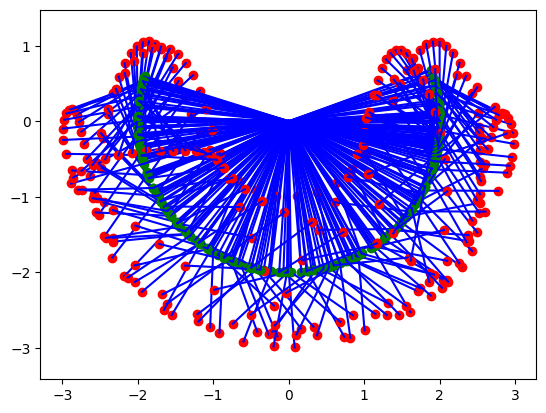

In [ ]:
fig = plt.figure()

c = Camera(fig)
plt.axis("equal")

#Ya hallamos las posiciones, solo es recorrelas y graficarlas
for i in range(250):
  #Posiciones partícula 1
  plt.plot(x_1[i],y_1[i],'go')
  #Posiciones partícula 2
  plt.plot(x_2[i],y_2[i],'ro')

  #gráfica de la varilla 1
  plt.plot([0, x_1[i]],[0,y_1[i]],'b-')
  #gráfica de la varilla 2
  plt.plot([x_1[i],x_2[i]],[y_1[i],y_2[i]],'b-')
  c.snap()

In [ ]:
#visualizamos la animación
fps=100
anim = c.animate(fps)
HTML(anim.to_html5_video())

**2. Compruebe con una solución particular , que las constantes de movimiento identificadas del sistema en la *PARTE 2*, son en realidad constantes.**



**3. Escriba un programa para resolver numéricamente las ecuaciones de movimiento obtenidas en la *PARTE 3.* Con condiciones iniciales apropiadas, resuelva las ecuaciones y haga una animación del movimiento del péndulo.**



In [ ]:
#creamos las funciones z1 y z2
func_q1_d = sp.lambdify((t,w1,w2,m1,m2,L1,L2,q1(t),q2(t),p1(t),p2(t)),
                        q1_punto_cano,np)
func_q2_d = sp.lambdify((t,w1,w2,m1,m2,L1,L2,q1(t),q2(t),p1(t),p2(t)),
                        q2_punto_cano,np)

#creamos las funciones: derivada de z1 y derivada de z2
func_p1_d = sp.lambdify((t,w1,w2,m1,m2,L1,L2,q1(t),q2(t),p1(t),p2(t)),
                        p1_punto_cano,np)
func_p2_d = sp.lambdify((t,w1,w2,m1,m2,L1,L2,q1(t),q2(t),p1(t),p2(t)),
                        p2_punto_cano,np)


In [ ]:
#Función que me recibe los parametros y la varible sobre la que se deriva (t)
def Dif_Ecu_H(A, t, w1, w2, m1, m2, L1, L2):
  #A contiene las ecuaciones de movimiento
  q_1, q_2, p_1, p_2 = A

  #retornamos las ecuaciones diferenciales
  return [func_q1_d(t,w1,w2,m1,m2,L1,L2,q_1,q_2,p_1,p_2),
          func_q2_d(t,w1,w2,m1,m2,L1,L2,q_1,q_2,p_1,p_2),
          func_p1_d(t,w1,w2,m1,m2,L1,L2,q_1,q_2,p_1,p_2),
          func_p2_d(t,w1,w2,m1,m2,L1,L2,q_1,q_2,p_1,p_2),
          ]

In [ ]:
#Resolvemos el sistema con Odeint
sol_H = odeint(Dif_Ecu_H,
               y0 = [100*deg, 0, 30*deg, 0],
               t=t_,
               args=(w_1,w_2,m_1,m_2,L_1,L_2))

In [ ]:
#Posiciones de las q_j
pos_q1 = sol_H.T[0]
pos_q2 = sol_H.T[1]

#función para hallar las posiciones de las partículas
def Posiciones_H(pos_1, pos_2, L1, L2):

    return (L1*np.sin(pos_1),
            -L1*np.cos(pos_1),
            L1*np.sin(pos_1) + L2*np.sin(pos_2),
            -L1*np.cos(pos_1) - L2*np.cos(pos_2))

x_1_H, y_1_H, x_2_H, y_2_H = Posiciones_H(pos_q1, pos_q2, L_1, L_2)

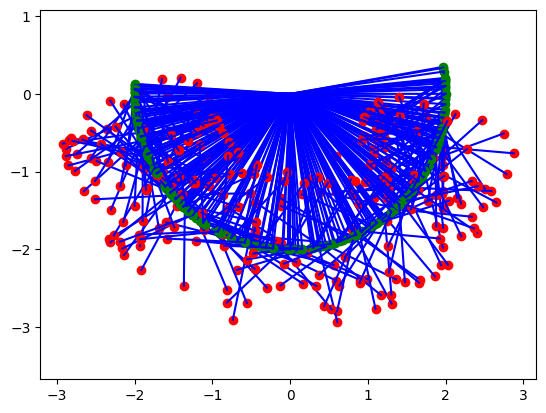

In [ ]:
fig = plt.figure()

c = Camera(fig)
plt.axis("equal")

#Ya hallamos las posiciones, solo es recorrelas y graficarlas
for i in range(250):
  #Posiciones partícula 1
  plt.plot(x_1_H[i],y_1_H[i],'go')
  #Posiciones partícula 2
  plt.plot(x_2_H[i],y_2_H[i],'ro')

  #gráfica de la varilla 1
  plt.plot([0, x_1_H[i]],[0,y_1_H[i]],'b-')
  #gráfica de la varilla 2
  plt.plot([x_1_H[i],x_2_H[i]],[y_1_H[i],y_2_H[i]],'b-')
  c.snap()

In [ ]:
fps=100
anim = c.animate(fps)
HTML(anim.to_html5_video())

**4. El espacio de fases del sistema tiene muchas dimensiones. Se puede reducir si si fijan algunas variables del sistema. Fije en 0 el valor de las variables y momentos generalizados de la partícula 1 y gráfique contornos del Hamiltoniano en el espacio de fase resultante con las variables y momentos generalizados de la partícula 2.**



Momentos generalizados

In [ ]:
#Partícula 1
pos_p1 = sol_H.T[2]

#Partícula 2
pos_p2 = sol_H.T[3]


In [ ]:
#Creamos la malla sobre la partícula 2
TETAS,PTETAS = np.meshgrid(pos_q2,pos_p2)

#Creamos la funcion del hamiltoniano
HS_ecu = sp.lambdify((t,w1,w2,m1,m2,L1,L2,q1(t),q2(t),p1(t),p2(t)), H , np)

#Calculamos el Hamiltoniano sobre la malla, con q1=0 y p1=0
HS = HS_ecu(t,w_1,w_2,m_1,m_2,L_1,L_2,0,TETAS,0,PTETAS)

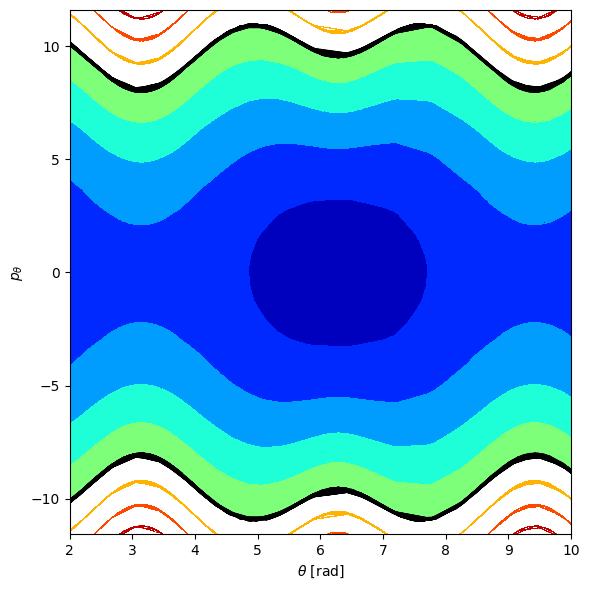

In [ ]:
fig=plt.figure(figsize=(6,6))
ax=fig.gca()


#Contorno de diferentes colores
c=ax.contourf(TETAS,PTETAS,HS,10,cmap="jet")

#Contorno de H=0 (linea negra)
c=ax.contour(TETAS,PTETAS,HS,[0],colors=['k'],linewidths=2)


ax.set_xlim((2,10))
ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel(r"$p_\theta$")
fig.tight_layout();

**5. Es bien sabido que el péndulo doble experimenta caos. Vamos a comprobarlo. Escoja condiciones iniciales arbitrarias para las variables (use las variables del formalismo Hamiltoniano). Grafique la evolución en el tiempo de las variables generalizadas de ambas partículas. Cambie ahora sutilmente las condiciones iniciales y estudie la evolución a largo plazo de las variables generalizadas.  Haga una animación que muestre la evolución del sistema con condiciones sutilmente diferentes como la que aparece [aquí](https://en.wikipedia.org/wiki/Double_pendulum#/media/File:Demonstrating_Chaos_with_a_Double_Pendulum.gif).**

In [ ]:
#Crearemos un segundo péndulo doble, con una variación de 1 grado en el q2
sol2_H = odeint(Dif_Ecu_H,
                y0=[100*deg, 0, 31*deg, 0],
                t=t_,
                args=(w_1,w_2,m_1,m_2,L_1,L_2))

Posiciones de las $q_j$

In [ ]:
#Péndulo 1
pos_q1 = sol_H.T[0]
pos_q2 = sol_H.T[1]

#Péndulo 2
pos2_q1 = sol2_H.T[0]
pos2_q2 = sol2_H.T[1]


Hallamos las posiciones de las partículas de los péndulos en las coordenas.

In [ ]:
#Péndulo 1
x_1_H, y_1_H, x_2_H, y_2_H = Posiciones_H(pos_q1, pos_q2, L_1, L_2)

#Péndulo 2
x_1_H2, y_1_H2, x_2_H2, y_2_H2 = Posiciones_H(pos2_q1, pos2_q2, L_1, L_2)

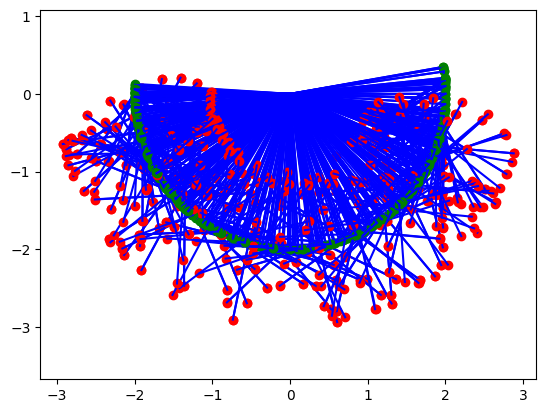

In [ ]:
fig = plt.figure()

c = Camera(fig)
plt.axis("equal")

#Ya hallamos las posiciones, solo es recorrelas y graficarlas
for i in range(250):
  ###Péndulo 1###
  #Posiciones partícula 1
  plt.plot(x_1_H[i],y_1_H[i],'go')
  #Posiciones partícula 2
  plt.plot(x_2_H[i],y_2_H[i],'ro')

  #gráfica de la varilla 1
  plt.plot([0, x_1_H[i]],[0,y_1_H[i]],'b-')
  #gráfica de la varilla 2
  plt.plot([x_1_H[i],x_2_H[i]],[y_1_H[i],y_2_H[i]],'b-')



  ###Péndulo 2###
  #Posiciones partícula 1
  plt.plot(x_1_H2[i],y_1_H2[i],'go')
  #Posiciones partícula 2
  plt.plot(x_2_H2[i],y_2_H2[i],'ro')

  #gráfica de la varilla 1
  plt.plot([0, x_1_H2[i]],[0,y_1_H2[i]],'b-')
  #gráfica de la varilla 2
  plt.plot([x_1_H2[i],x_2_H2[i]],[y_1_H2[i],y_2_H2[i]],'b-')

  c.snap()

In [ ]:
fps=100
anim = c.animate(fps)
HTML(anim.to_html5_video())

### A partir del segundo 17 se empieza a notar el desfase